# Airbnb Price Prediction: Exploratory Data Analysis (EDA)

## Problem Statement

The objective of this project is to develop a machine learning multivariate regression model that can effectively predict the *log-transformed price* (`log_price`) of Airbnb listings based on their features. By leveraging various attributes such as room type, number of guests accommodated, number of bedrooms and bathrooms, cancellation policy, cleaning fee, booking options, guest ratings, and more, the model aims to provide reliable price estimates for both existing and new property listings. 

An effective price prediction model can help Airbnb hosts optimize listing prices, enhance competitiveness, and improve the overall user experience for guests seeking accommodations.

## Data Dictionary

The dataset contains the following columns:

- **id:** Unique identifier for the listing
- **room_type:** Type of the room/property (e.g., entire home, private room)
- **accommodates:** Number of guests the property can accommodate
- **bathrooms:** Number of bathrooms
- **cancellation_policy:** The type of cancellation policy for the listing
- **cleaning_fee:** Whether a cleaning fee is charged
- **instant_bookable:** Whether the property can be booked instantly
- **review_scores_rating:** Average rating score of the listing
- **bedrooms:** Number of bedrooms
- **beds:** Number of beds
- **log_price:** Log-transformed price of the listing (target variable)

## Data Loading and Initial Exploration

Let's import the necessary libraries, load the dataset, and take an initial look at the data to understand its structure.

In [20]:
import os
cwd = os.getcwd()
cwd

'c:\\Users\\kushal_msi\\Documents\\Portfolio_projects\\Python\\air-bnb-price-prediction\\notebooks'

In [21]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_excel('../data/Air_BNB.xlsx', sheet_name='Air_BNB')  # Adjust path/filename if needed

# Display the first few rows
df.head()

,id,room_type,accommodates,bathrooms,cancellation_policy,cleaning_fee,instant_bookable,review_scores_rating,bedrooms,beds,log_price
0,6901257,Entire home/apt,3.0,1.0,strict,1.0,f,100.0,1.0,1.0,5.010635
1,6304928,Entire home/apt,7.0,1.0,strict,1.0,t,93.0,3.0,3.0,5.129899
2,7919400,Entire home/apt,5.0,1.0,moderate,1.0,t,92.0,1.0,3.0,4.976734
3,13418779,Entire home/apt,4.0,1.0,flexible,1.0,f,NaN,2.0,2.0,6.620073
4,3808709,Entire home/apt,2.0,1.0,moderate,1.0,t,40.0,0.0,1.0,4.744932


In [22]:
print("Dataset shape:", df.shape)
print("Column names:", df.columns.tolist())

Dataset shape: (74111, 11)
Column names: ['id', 'room_type', 'accommodates', 'bathrooms', 'cancellation_policy', 'cleaning_fee', 'instant_bookable', 'review_scores_rating', 'bedrooms', 'beds', 'log_price']


### Initial Observations

- The dataset contains **74,111 rows** and **11 columns**.
- The columns are:
    - `id`
    - `room_type`
    - `accommodates`
    - `bathrooms`
    - `cancellation_policy`
    - `cleaning_fee`
    - `instant_bookable`
    - `review_scores_rating`
    - `bedrooms`
    - `beds`
    - `log_price` (target variable; log-transformed price)
- This rich set of features will allow us to analyze and model Airbnb listing prices.

## Data Types and Missing Values

Let's check the datatypes of each column and see if there are any missing values to handle.

In [23]:
# Data types and non-null counts
df.info()

# Count missing values in each column
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    74111 non-null  int64  
 1   room_type             74106 non-null  object 
 2   accommodates          74108 non-null  float64
 3   bathrooms             73908 non-null  float64
 4   cancellation_policy   74103 non-null  object 
 5   cleaning_fee          74107 non-null  float64
 6   instant_bookable      74111 non-null  object 
 7   review_scores_rating  57389 non-null  float64
 8   bedrooms              74019 non-null  float64
 9   beds                  73980 non-null  float64
 10  log_price             74111 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 6.2+ MB


id                          0
room_type                   5
accommodates                3
bathrooms                 203
cancellation_policy         8
cleaning_fee                4
instant_bookable            0
review_scores_rating    16722
bedrooms                   92
beds                      131
log_price                   0
dtype: int64

## Data Types and Missing Values

- The dataset contains a mix of numerical and categorical features.
- **Missing values are present in several columns:**
    - `review_scores_rating`: 16,722 missing (most affected column)
    - `bathrooms`: 203 missing
    - `beds`: 131 missing
    - `bedrooms`: 92 missing
    - `cleaning_fee`: 4 missing
    - `accommodates`: 3 missing
    - `room_type`: 5 missing
    - `cancellation_policy`: 8 missing
- The target variable `log_price`, as well as `id` and `instant_bookable`, have no missing values.
- Most missingness is light, except for `review_scores_rating` (which has a substantial portion missing).

> **Note:** Special attention will be needed for `review_scores_rating` during data cleaning and modeling due to its high count of missing values.

## Statistical Summary of Numeric Features

In [24]:
round(df.describe().T, 2)

,count,mean,std,min,25%,50%,75%,max
id,74111.0,11266617.10,6081734.89,344.0,6261964.50,12254147.00,16402260.50,21230903.0
accommodates,74108.0,3.16,2.15,1.0,2.00,2.00,4.00,16.0
bathrooms,73908.0,1.24,0.58,0.0,1.00,1.00,1.00,8.0
cleaning_fee,74107.0,0.73,0.44,0.0,0.00,1.00,1.00,1.0
review_scores_rating,57389.0,94.07,7.84,20.0,92.00,96.00,100.00,100.0
bedrooms,74019.0,1.27,0.85,0.0,1.00,1.00,1.00,10.0
beds,73980.0,1.71,1.25,0.0,1.00,1.00,2.00,18.0
log_price,74111.0,4.78,0.72,0.0,4.32,4.71,5.22,7.6


## Statistical Summary of Numeric Features

- **accommodates:** Most listings host 2–4 guests (median 2, 75th percentile 4, max 16). Very large values may be outliers or unique group properties. Acceptable thresholds can be defined in consultation with domain experts.
- **bathrooms:** The majority of listings report 1 bathroom; maximum is 8. Properties with very high bathroom counts should be investigated as potential data entry errors or niche listings.
- **cleaning_fee:** Encoded as a float 0 or 1, likely indicating the absence or presence of a cleaning fee (0 = No, 1 = Yes).
- **review_scores_rating:** Scores mainly range from 20 to 100, averaging around 94. Exceptionally low values may be due to limited reviews or data quality issues.
- **bedrooms:** Median is 1, but the maximum is 10, which may reflect unusually large accommodations or errors.
- **beds:** Typically, listings provide 1–2 beds; values as high as 18 could be special cases or data entry mistakes.
- **log_price:** The target, log-transformed price, ranges from ~4.3 to 7.6, with a median of 4.71. Transformation reduces skew and the influence of high-value outliers. However, a minimum value of 0.0 suggests possible anomalies or placeholder values that should be further investigated.

**Insights & Next Steps:**
- Most features fall within expected ranges, but several have high maximum values that may indicate outliers or data errors.
- Special attention will be given to extreme values and target variable anomalies during the data cleaning phase.
- The binary encoding of `cleaning_fee` should be confirmed by reviewing unique values.


## Feature Distributions and Visual Exploration

Let's visualize the distribution of the target variable (`log_price`) and some key features to better understand their spread and spot potential outliers or skewness.

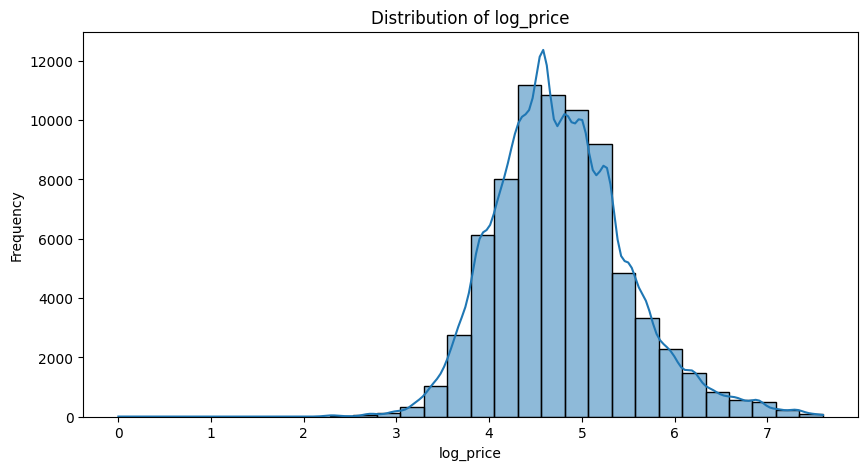

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of log_price
plt.figure(figsize=(10,5))
sns.histplot(df['log_price'], bins=30, kde=True)
plt.title('Distribution of log_price')
plt.xlabel('log_price')
plt.ylabel('Frequency')
plt.show()

**log_price**:  
  The distribution of the log-transformed price is approximately normal, with a slight right skew, thanks to log transformation. There are very few low outliers and a long tail at the high end, indicating some high-priced listings. Modeling with the log-transformed target helps to stabilize variance and makes the regression problem more tractable.

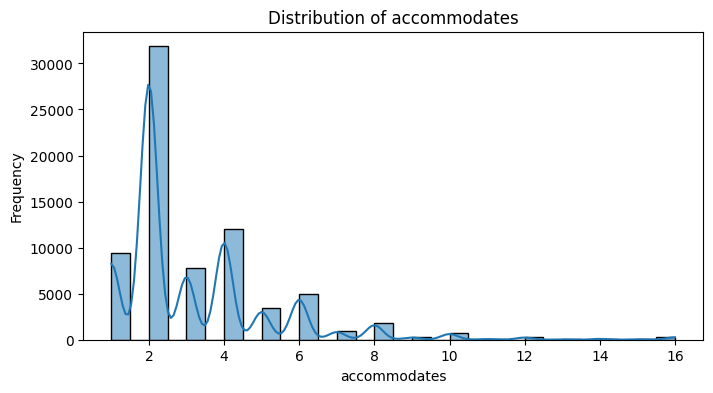

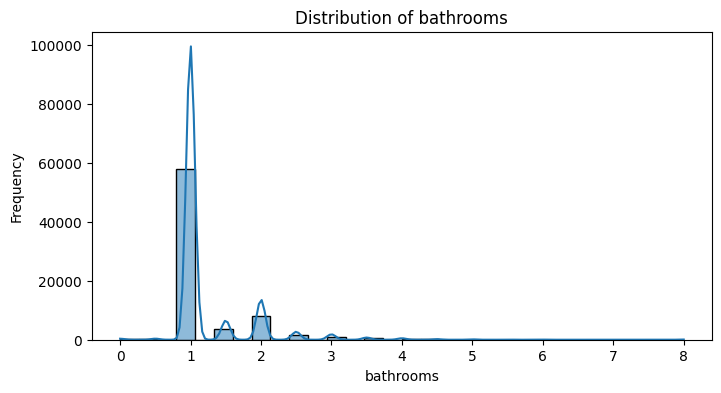

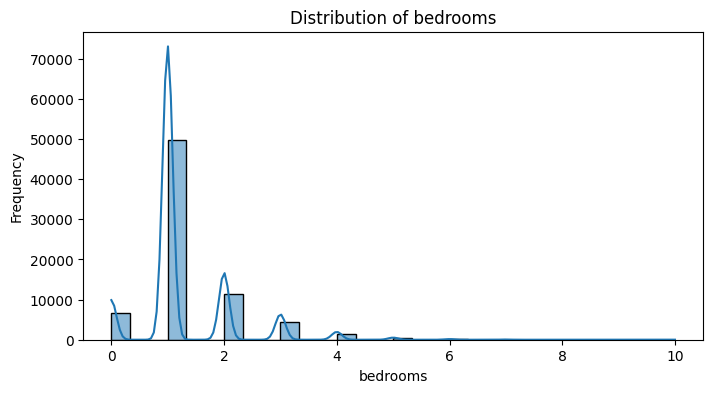

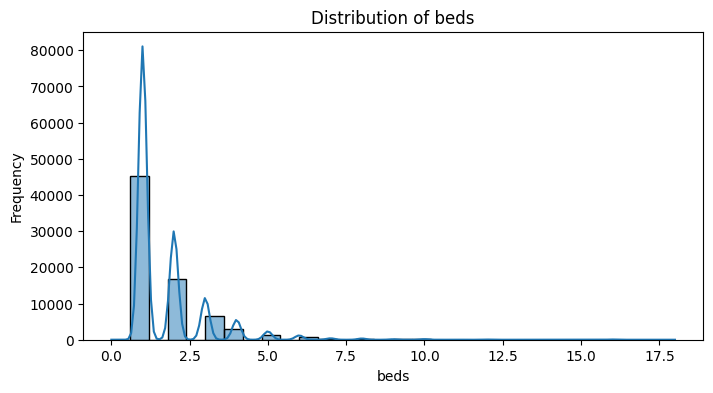

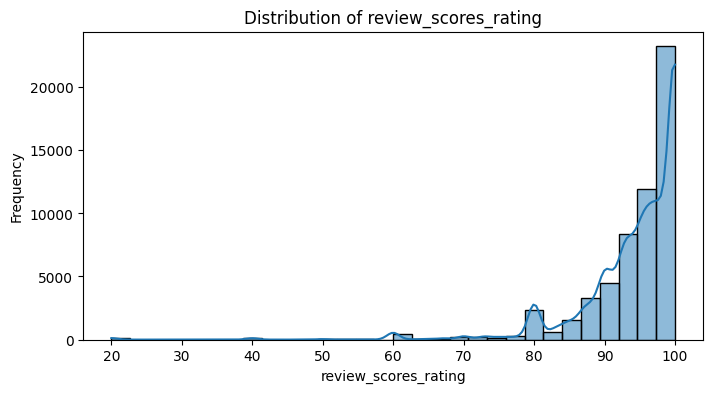

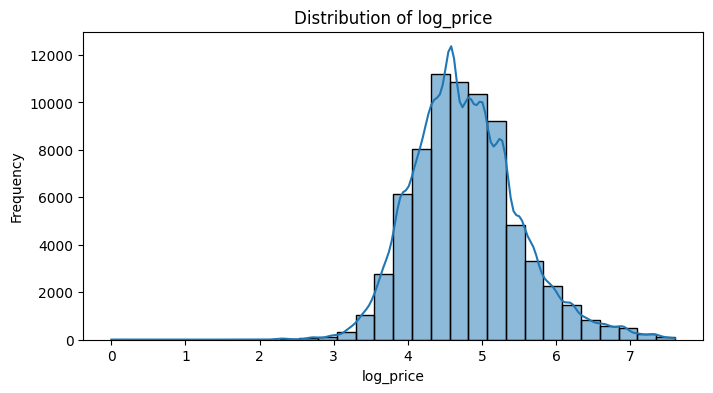

In [26]:
# Numeric Feature Distributions
numeric_features = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'review_scores_rating','log_price']

for col in numeric_features:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col].dropna(), kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

### Numerical Features

- **accommodates**:  
  The vast majority of listings accommodate 2-4 guests, with clear peaks at 2 and 4. Higher values are increasingly rare, but a few listings cater to much larger groups, likely specialized or luxury properties. The distribution has visible spikes, possibly indicating common configurations (e.g., 2, 4, 6 guests).

- **bathrooms**:  
  Most properties offer 1 bathroom, with a steep drop-off for higher counts. A small number of listings have more than 2 bathrooms potentially large or premium listings, or possibly data entry errors at the extreme values (6-8).

- **bedrooms**:  
  The distribution is sharply centered at 1 bedroom, with a secondary smaller peak at 2. Listings with 3 or more bedrooms are rare, and a very small number have high bedroom counts (up to 10), which may be outliers or unique cases (e.g., large group rentals). There are also listings labeled with 0 bedrooms, which could represent studio apartments or data entry mistakes.

- **beds**:  
  Most listings offer 1 or 2 beds, with a rapid decline for higher counts. A few listings report a very high number of beds (over 10), which, like the high bedroom counts, may represent unusual properties or data entry errors.

- **review_scores_rating**:  
  The vast majority of ratings cluster between 90 and 100, showing that most hosts have very good reviews. There is a long left tail listings with lower ratings are relatively rare, possibly indicating new listings, problematic properties, or those with insufficient number of reviews.


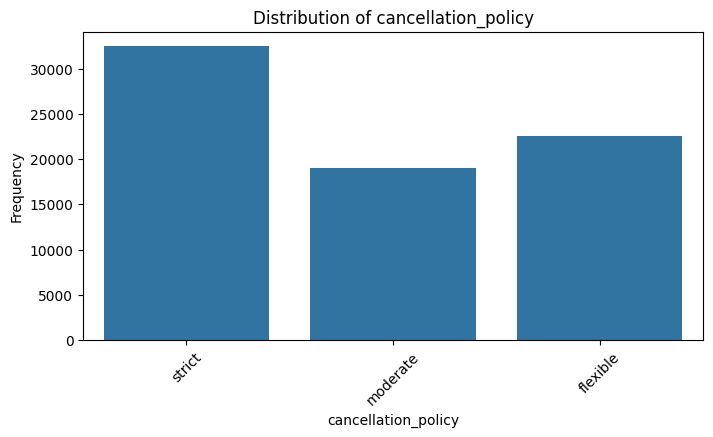

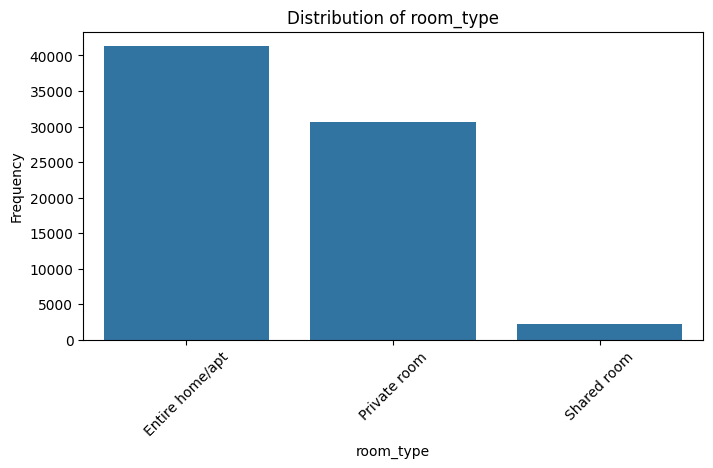

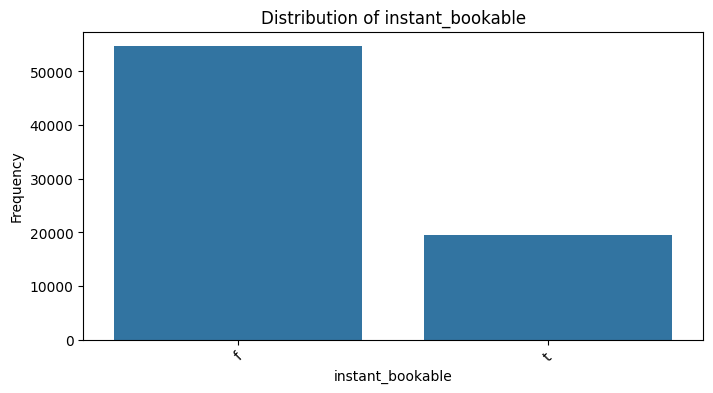

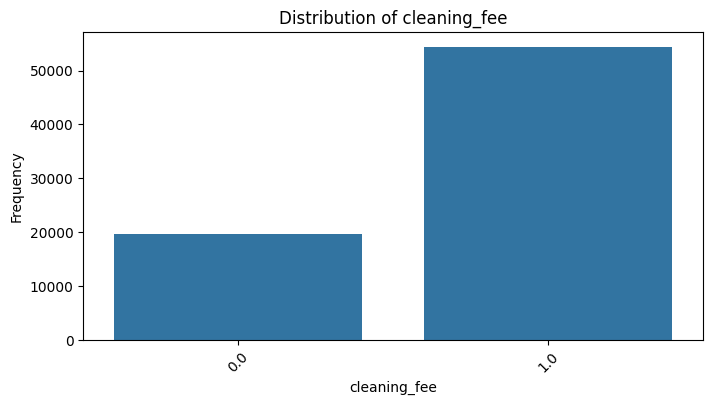

In [27]:
# Categorical Feature Distributions
categorical_features = ['cancellation_policy', 'room_type', 'instant_bookable','cleaning_fee']

for col in categorical_features:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.show()


### Categorical Features

- **cancellation_policy**:  
  The "strict" policy is the most common, followed by "flexible" and "moderate." This suggests many hosts prefer more control over cancellations, though a significant portion are willing to offer more lenient terms.

- **room_type**:  
  "Entire home/apt" is the most frequently listed room type, followed by "private room." "Shared room" listings are much less common, indicating most users value privacy or exclusive access.

- **instant_bookable**:  
  The dataset has more listings that are instant bookable than those requiring manual approval. However, a substantial minority of listings are not instant bookable, which may impact a guest's booking convenience.

- **cleaning_fee**:  
  A clear majority of listings charge a cleaning fee (1.0), but a sizeable minority do not (0.0). This split could affect overall pricing and attractiveness to potential guests.


### General Insights

- Distributions of key numerical features are highly right-skewed, with most listings catering to small groups and a few significant outliers (large properties).
- Categorical variables generally show dominant categories but also maintain meaningful variety, which will be useful for modeling.
- The prevalence of extreme values or zeros in attributes like bedrooms, beds, or bathrooms should be examined further, these may need cleaning or special feature engineering.
- The strong concentration of high review scores and frequent presence of cleaning fees or instant booking indicates competitive and guest-friendly market practices.

## Handling Duplicates and Dataset Variants

To analyze the impact of duplicates on model performance, we created two versions of the dataset:
- **Original Dataset (`df_original`)**: All records included, with the unique `id` column retained for traceability but excluded for modeling.
- **Deduplicated Dataset (`df_nodup`)**: Exact duplicates (rows with identical features and target) dropped, and the `id` column excluded. This ensures each unique listing configuration only appears once.

Both datasets will be cleaned (for missing values, etc.) and used for model comparison.

In [28]:
# Original with ID (for traceability; don't use 'id' in modeling)
df_original = df.copy()

# Deduplicated version - drop duplicates based on all features except 'id'
feature_cols = df.columns.difference(['id'])
df_nodup = df.drop_duplicates(subset=feature_cols).reset_index(drop=True)

# Optionally drop 'id' column for modeling in deduplicated version
df_nodup_nid = df_nodup.drop(columns=['id']) #(optional)

In [29]:
# Check for df_original shape
df_original.shape

(74111, 11)

In [30]:
# Check for df_nodup shape
df_nodup.shape

(54117, 11)

In [31]:
# Duplicates excluding 'id' column
df_original.shape[0] - df_nodup.shape[0]

19994

There are 19994 duplicates when id feature is excluded from the dataset

## Data Cleaning: Handling Missing Values

Both datasets undergo the same missing value handling to ensure a fair comparison in modeling. Numerical columns are imputed with the median; categorical columns with the mode.

In [32]:
# review missing values percentage for df_original
round(df_original.isnull().sum()/df_original.shape[0] * 100, 2)

id                       0.00
room_type                0.01
accommodates             0.00
bathrooms                0.27
cancellation_policy      0.01
cleaning_fee             0.01
instant_bookable         0.00
review_scores_rating    22.56
bedrooms                 0.12
beds                     0.18
log_price                0.00
dtype: float64

In [33]:
# review missing values percentage for df_nodup
round(df_nodup.isnull().sum()/df_nodup.shape[0] * 100, 2)

id                       0.00
room_type                0.01
accommodates             0.01
bathrooms                0.36
cancellation_policy      0.01
cleaning_fee             0.01
instant_bookable         0.00
review_scores_rating    18.88
bedrooms                 0.17
beds                     0.23
log_price                0.00
dtype: float64

In [34]:
# Cleaning Function
def clean_airbnb_df(df):
    # Fill numeric nulls with median
    for col in ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'review_scores_rating']:
        df[col] = df[col].fillna(df[col].median())
    # Fill categorical nulls with mode
    for col in ['room_type', 'cancellation_policy']:
        df[col] = df[col].fillna(df[col].mode()[0])
    # Fill cleaning_fee nulls with mode
    df['cleaning_fee'] = df['cleaning_fee'].fillna(df['cleaning_fee'].mode()[0])
    return df

# Clean both dataframes
df_original_clean = clean_airbnb_df(df_original.copy())
df_nodup_clean = clean_airbnb_df(df_nodup.copy())

In [35]:
# Check for missing values after cleaning
df_original_clean.isnull().sum()  

id                      0
room_type               0
accommodates            0
bathrooms               0
cancellation_policy     0
cleaning_fee            0
instant_bookable        0
review_scores_rating    0
bedrooms                0
beds                    0
log_price               0
dtype: int64

In [36]:
# Check for missing values after cleaning
df_nodup_clean.isnull().sum()  

id                      0
room_type               0
accommodates            0
bathrooms               0
cancellation_policy     0
cleaning_fee            0
instant_bookable        0
review_scores_rating    0
bedrooms                0
beds                    0
log_price               0
dtype: int64

All missing values in both datasets were handled using the median for numeric columns and the mode for categorical columns. The `id` column is retained for reference and traceability, and will be excluded prior to model training.

In [37]:
from sklearn.impute import KNNImputer

# Only use for numeric columns
knn_imputer = KNNImputer(n_neighbors=5)
df_numeric = df.select_dtypes(include=[np.number])
df_numeric_imputed = pd.DataFrame(knn_imputer.fit_transform(df_numeric), columns=df_numeric.columns)
# Then put back with other columns if needed

In [38]:
df_numeric_imputed.head()

,id,accommodates,bathrooms,cleaning_fee,review_scores_rating,bedrooms,beds,log_price
0,6901257.0,3.0,1.0,1.0,100.0,1.0,1.0,5.010635
1,6304928.0,7.0,1.0,1.0,93.0,3.0,3.0,5.129899
2,7919400.0,5.0,1.0,1.0,92.0,1.0,3.0,4.976734
3,13418779.0,4.0,1.0,1.0,95.6,2.0,2.0,6.620073
4,3808709.0,2.0,1.0,1.0,40.0,0.0,1.0,4.744932


In [39]:
# Fill NaNs in categorical columns with mode
df_cat = df[['room_type', 'cancellation_policy', 'instant_bookable']].copy()
df_cat['room_type'] = df_cat['room_type'].fillna(df_cat['room_type'].mode()[0])
df_cat['cancellation_policy'] = df_cat['cancellation_policy'].fillna(df_cat['cancellation_policy'].mode()[0])
# instant_bookable has no NaNs

# Reset index to align with df_numeric_imputed if needed
df_cat = df_cat.reset_index(drop=True)
df_numeric_imputed = df_numeric_imputed.reset_index(drop=True)

# Concatenate numeric and categorical columns
df_final_imputed = pd.concat([df_numeric_imputed, df_cat], axis=1)
# df_final now contains all numeric columns (imputed) and categorical columns

In [40]:
# Reorder columns to match original df
df_final_imputed = df_final_imputed[df.columns]

In [41]:
# Check for missing values in the final imputed dataframe
df_final_imputed.isnull().sum()

id                      0
room_type               0
accommodates            0
bathrooms               0
cancellation_policy     0
cleaning_fee            0
instant_bookable        0
review_scores_rating    0
bedrooms                0
beds                    0
log_price               0
dtype: int64

df_final_imputed is another dataframe which has all its numeric features missing values replaced with KNNImputer and the categorical features missing values with their respective modes.

In [42]:
# Bivariate Analysis Function
def bivariate_analysis(df,df_name="DataFrame"):
    """
    Perform bivariate analysis between two columns in a DataFrame.
    
    Parameters:
    - df: DataFrame containing the data
    """
    
    # Scatter plot for numeric vs numeric
    for col in ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'review_scores_rating']:
        plt.figure(figsize=(8,4))
        sns.scatterplot(x=df[col], y=df['log_price'])
        plt.title(f'{col} vs. log_price for {df_name}')
        plt.show()

    # box plot for categorical vs numeric
    for col in ['room_type', 'cancellation_policy', 'instant_bookable']:
        plt.figure(figsize=(8,4))
        sns.boxplot(x=df[col], y=df['log_price'])
        plt.title(f'{col} vs. log_price for {df_name}')
        plt.xticks(rotation=45)
        plt.show()
        

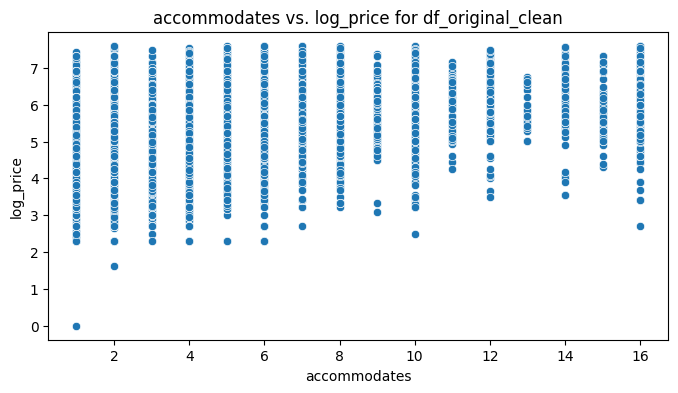

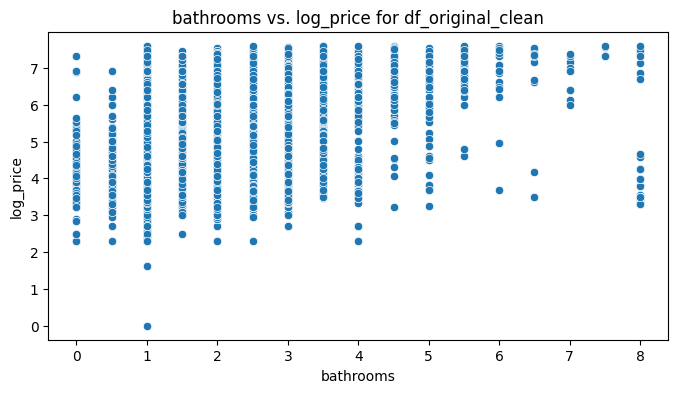

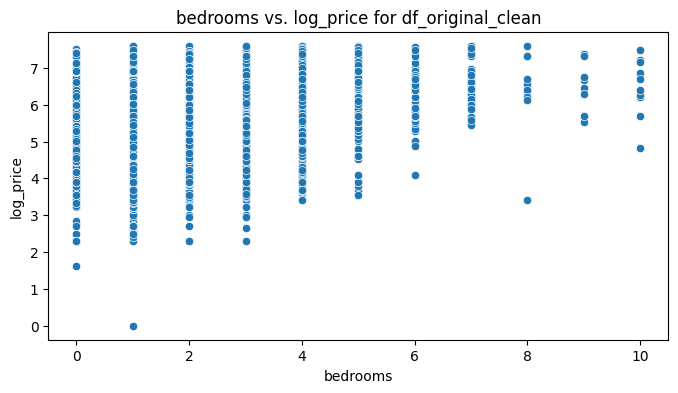

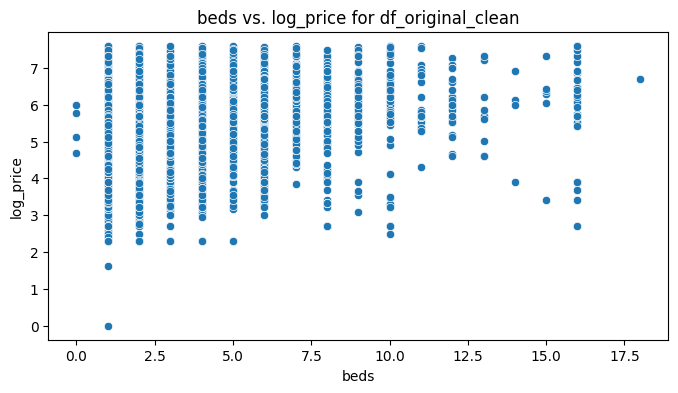

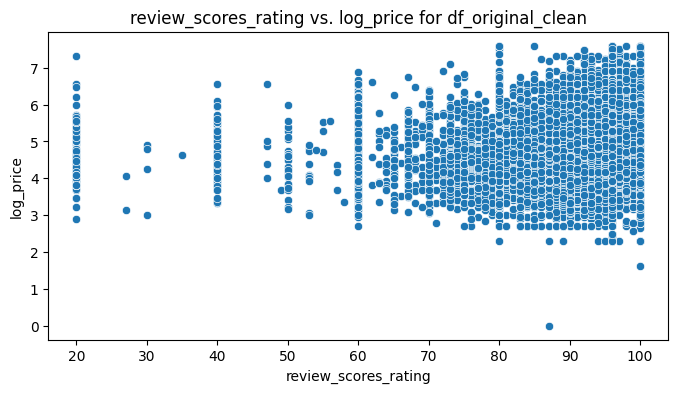

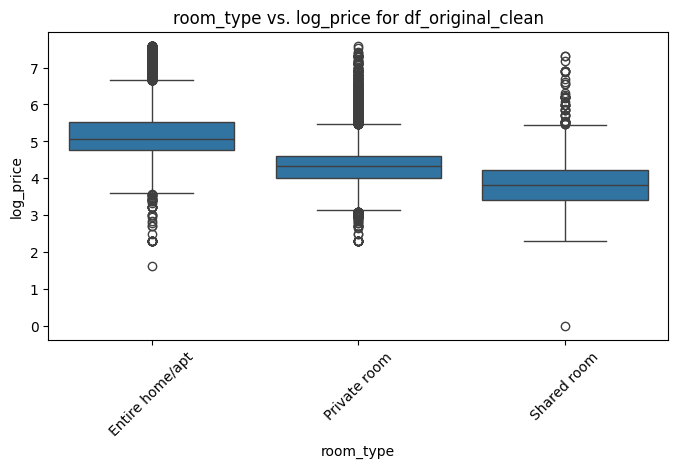

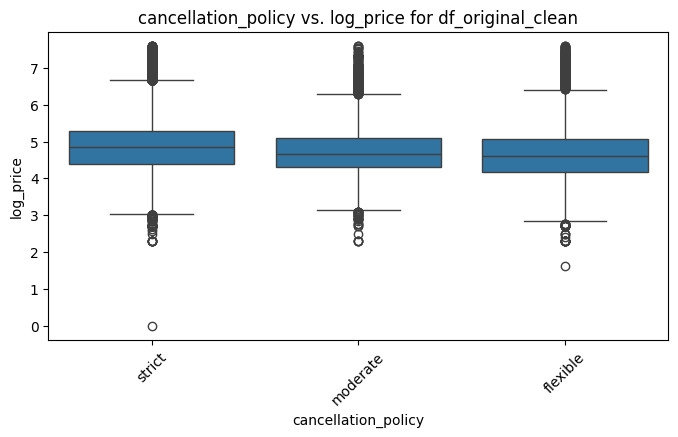

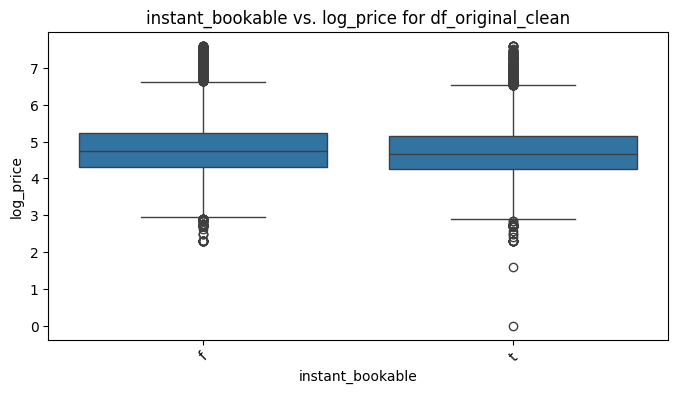

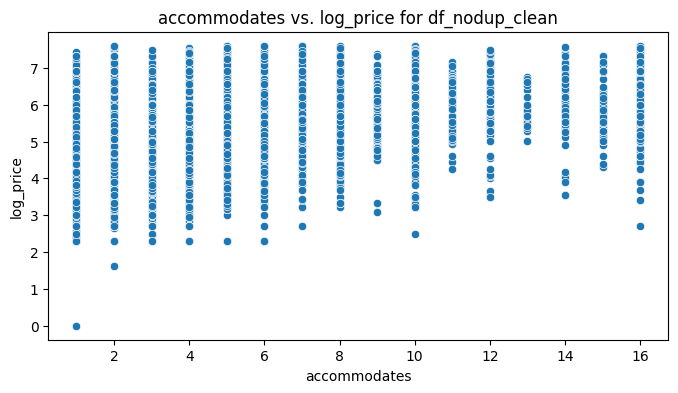

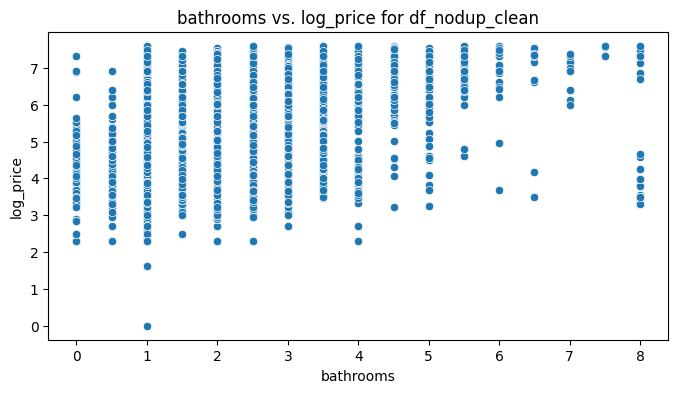

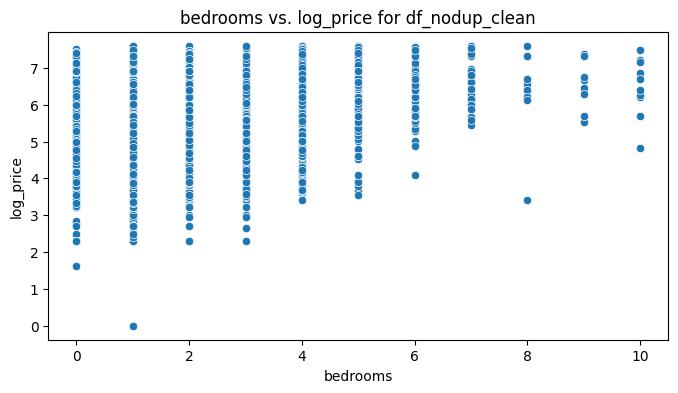

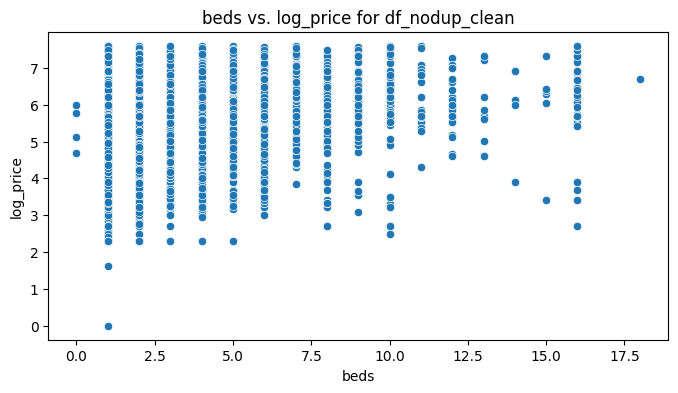

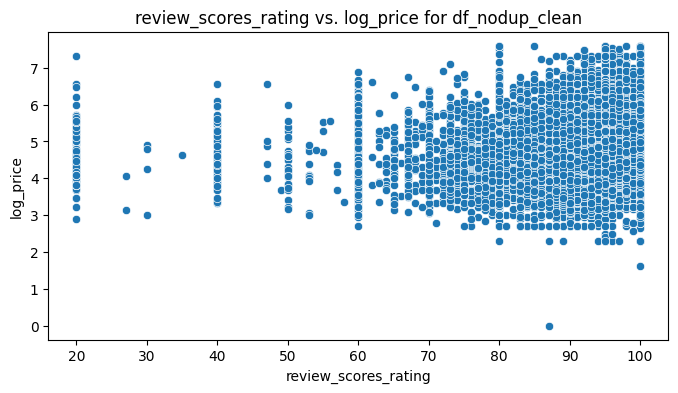

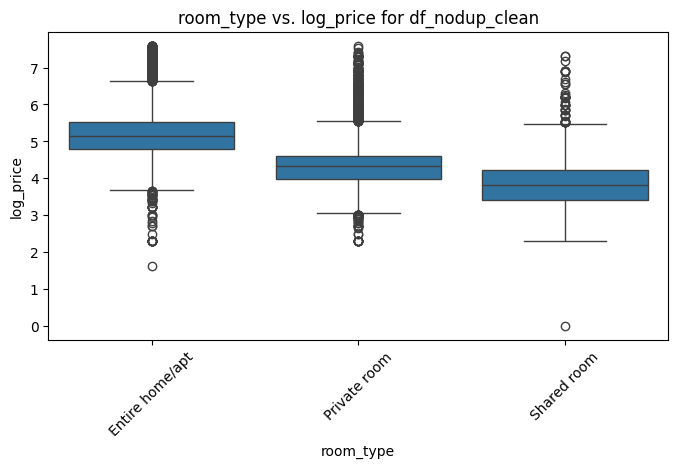

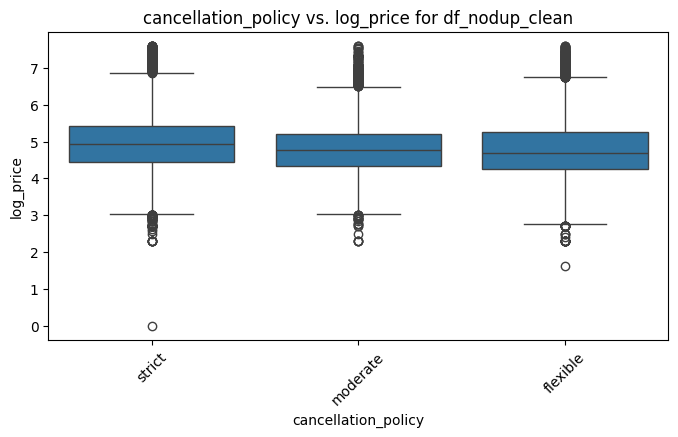

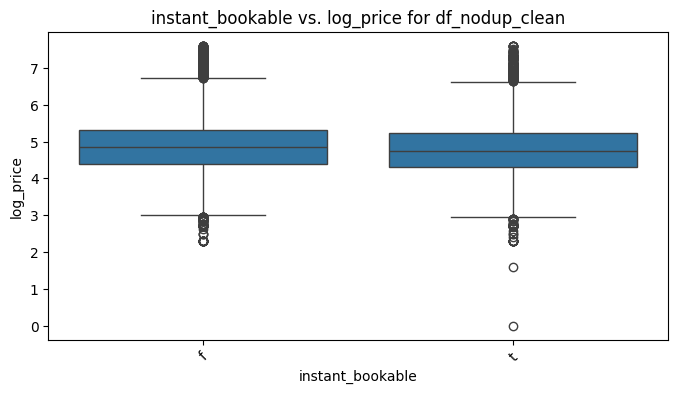

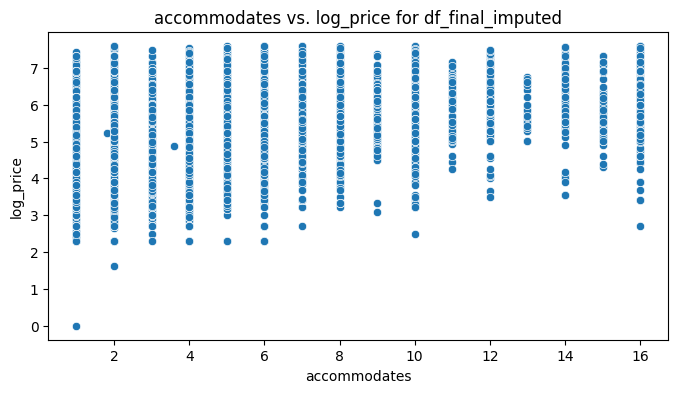

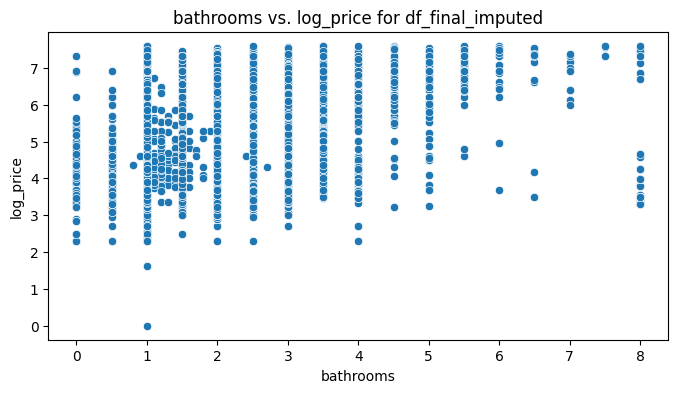

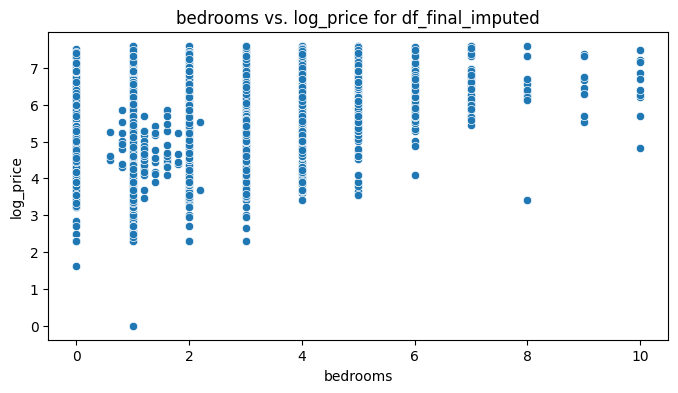

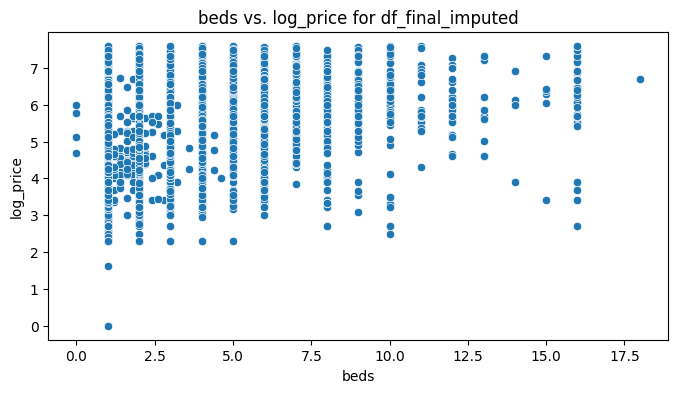

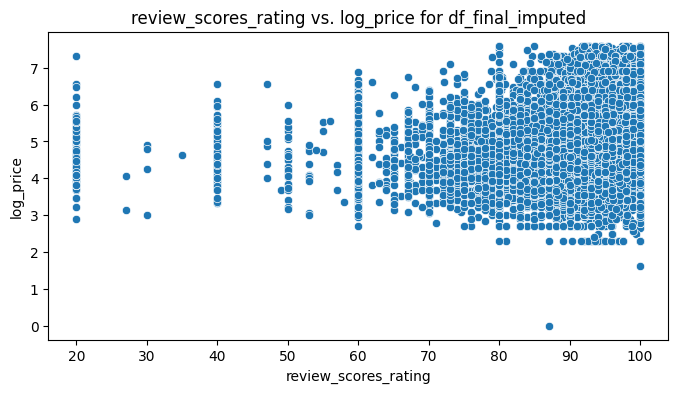

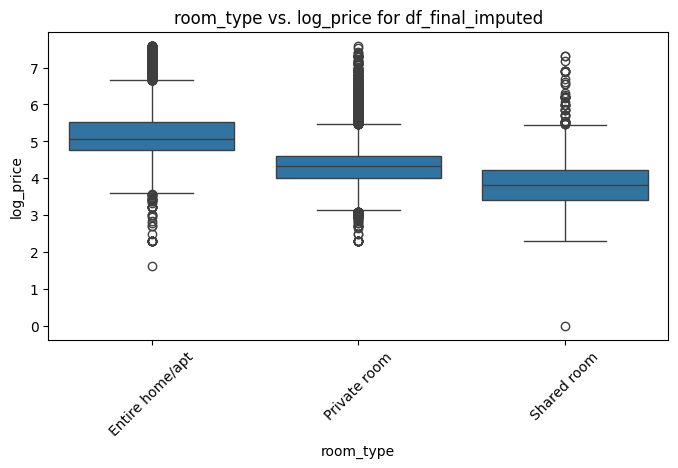

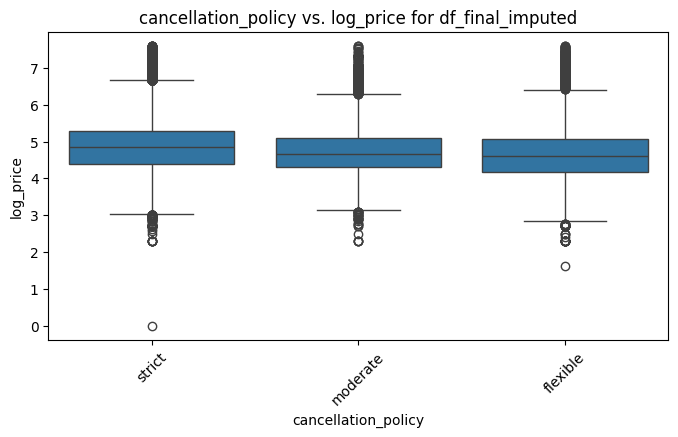

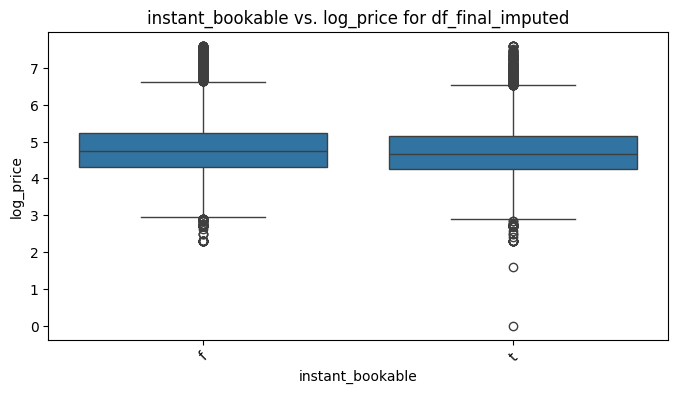

In [43]:
# Bivariate Analysis for df_original_clean
bivariate_analysis(df_original_clean,"df_original_clean")

# Bivariate Analysis for df_nodup_clean
bivariate_analysis(df_nodup_clean,"df_nodup_clean")

# Bivariate Analysis for df_final_imputed
bivariate_analysis(df_final_imputed,"df_final_imputed")

### Bivariate Analysis Insights

- **Numeric Features vs. log_price:**  
  - All numeric features (`accommodates`, `bathrooms`, `bedrooms`, `beds`, `review_scores_rating`) show a positive association with price, but the effect flattens at higher values.
  - Outliers are present for larger properties; most listings cluster at lower values.

- **Categorical Features vs. log_price:**  
  - `Entire home/apt` and `strict` cancellation policy listings have higher median prices.
  - `room_type` and `cancellation_policy` are strong predictors of price.
  - `instant_bookable` shows little impact on price.

> These relationships will guide feature selection, encoding, and further

In [44]:
# Correlation heatmap for numeric features
def correlation_heatmap(df, df_name="DataFrame"):
    plt.figure(figsize=(8,6))
    corr = df.select_dtypes(include=[np.number]).corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title(f'Correlation Matrix of Numeric Features for {df_name}')
    plt.show()

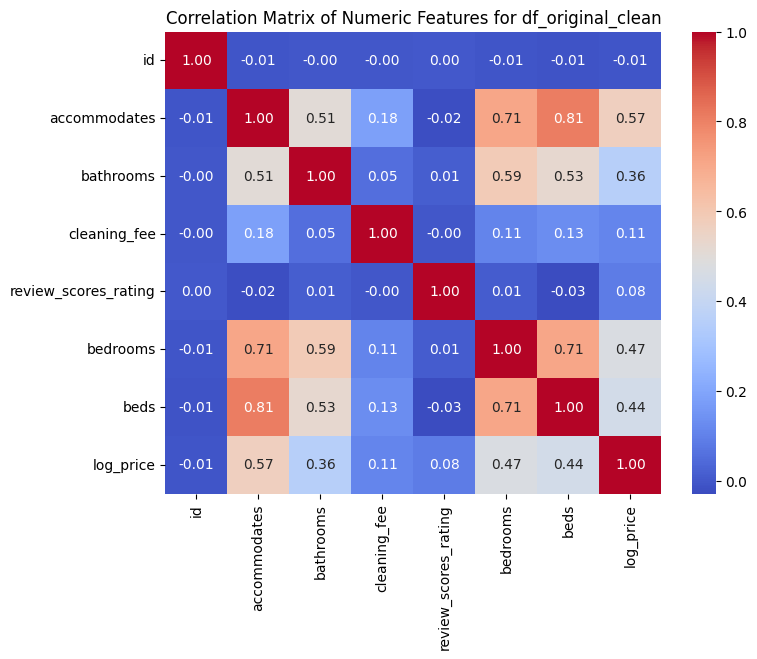

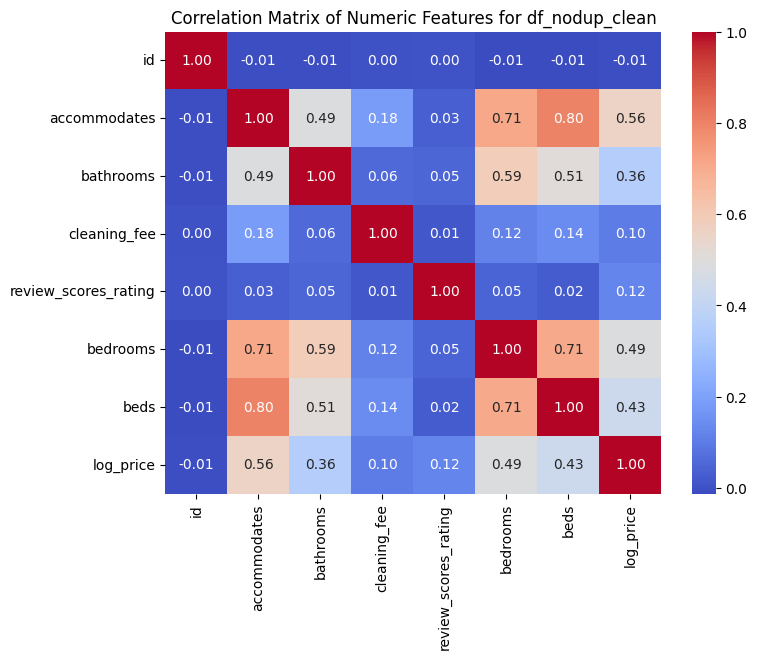

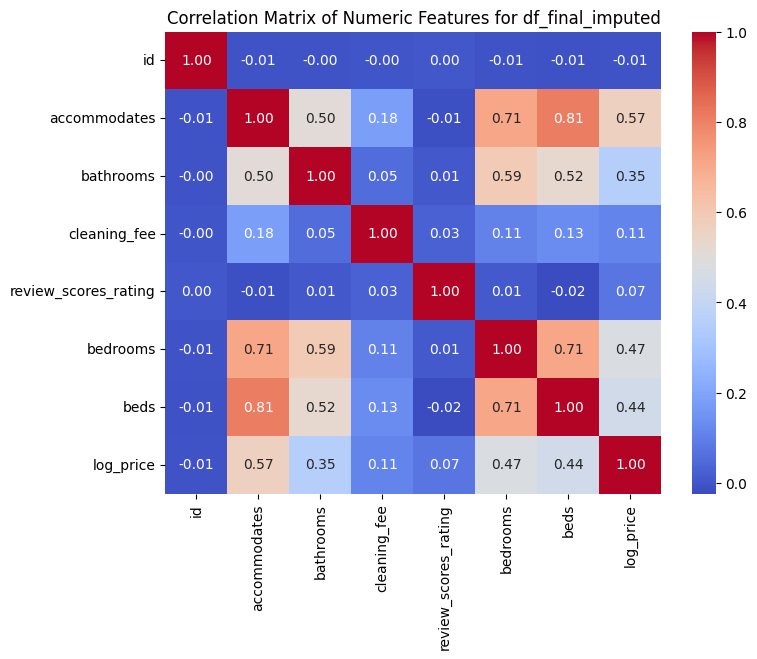

In [45]:
# correlation heatmap for df_original_clean
correlation_heatmap(df_original_clean, "df_original_clean")

# correlation heatmap for df_nodup_clean
correlation_heatmap(df_nodup_clean, "df_nodup_clean")

# correlation heatmap for df_final_imputed
correlation_heatmap(df_final_imputed, "df_final_imputed")


### Bivariate Analysis Insights

- **Numeric Features vs. log_price:**  
  - All numeric features (`accommodates`, `bathrooms`, `bedrooms`, `beds`, `review_scores_rating`) show a positive association with price, with the effect flattening at higher values.
  - Outliers are present for larger properties; most listings cluster at lower values.
  - These patterns are consistent across `df_original_clean`, `df_nodup_clean`, and `df_final_imputed`, with deduplication and imputation slightly reducing noise and outlier impact.

- **Categorical Features vs. log_price:**  
  - Listings with `Entire home/apt` and `strict` cancellation policy have higher median prices.
  - `room_type` and `cancellation_policy` are strong predictors of price.
  - `instant_bookable` shows little impact on price.
  - Distribution patterns remain similar across all three DataFrames, confirming robustness of categorical effects.

---

### Correlation Insights

- The correlation matrix highlights how numeric features relate to each other and to `log_price`.
- `accommodates`, `bedrooms`, `beds` and `bathrooms` show moderate positive correlation with `log_price`.
- Some features (e.g., `accommodates` and `bedrooms`) are also correlated with each other, indicating possible multicollinearity.
- The correlation structure is stable across all three DataFrames, with minor changes due to deduplication and imputation.
- These insights will guide feature selection and engineering

### Outlier Treatment

In [46]:
# box plot of all numeric features function for all dataframes
def outliers_plot(df,df_name='Dataframe'):
    """
    Plot boxplots for all numeric features in a dataframe.

    Args:
        df (pd.DataFrame): The dataframe to plot.
        df_name (str, optional): The name of the dataframe. Defaults to 'Dataframe'.
    """
    cont = df.select_dtypes(include=[np.number]).columns.drop('id', errors='ignore')
    plt.figure(figsize=(15, 10))
    df[cont].boxplot(vert=False)
    plt.title(f'with outliers for {df_name}', fontsize=15)
    plt.show()

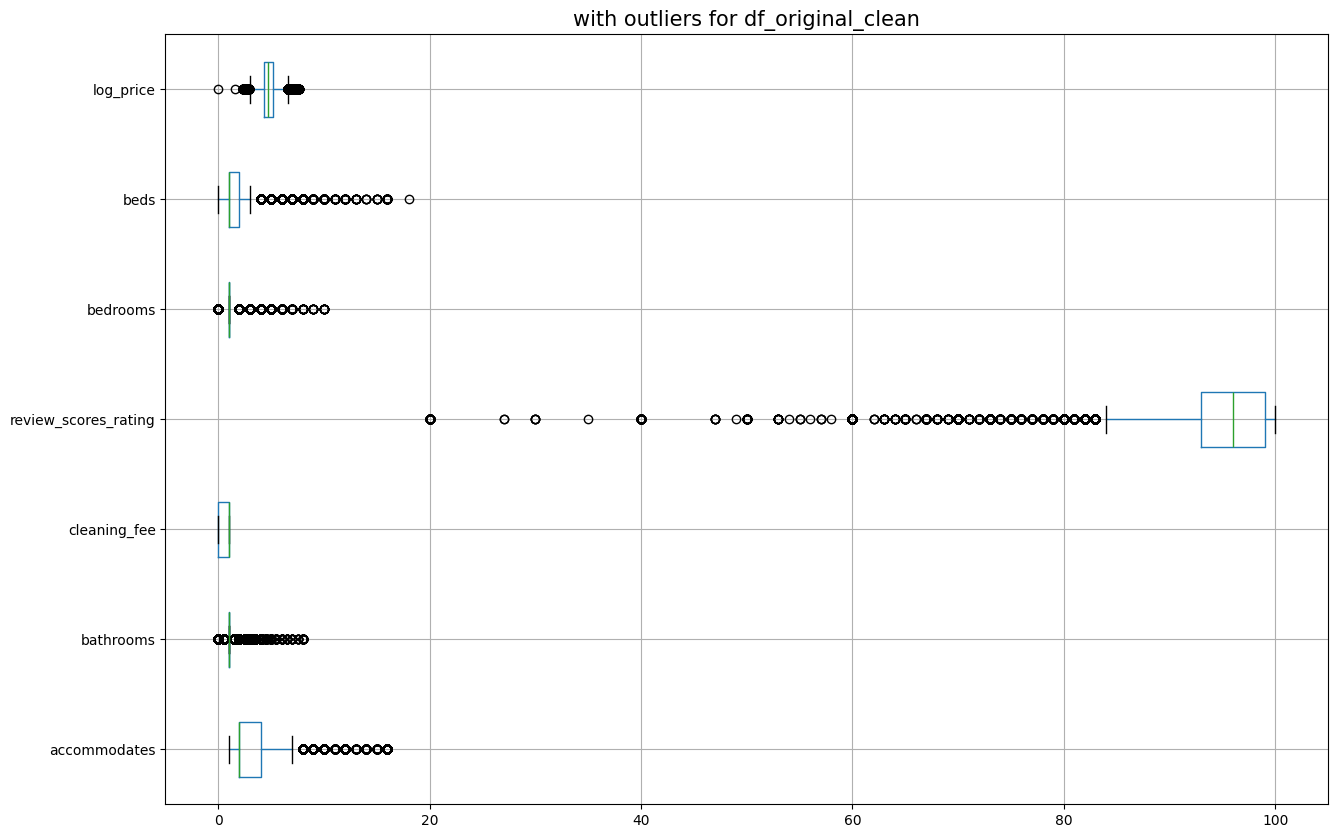

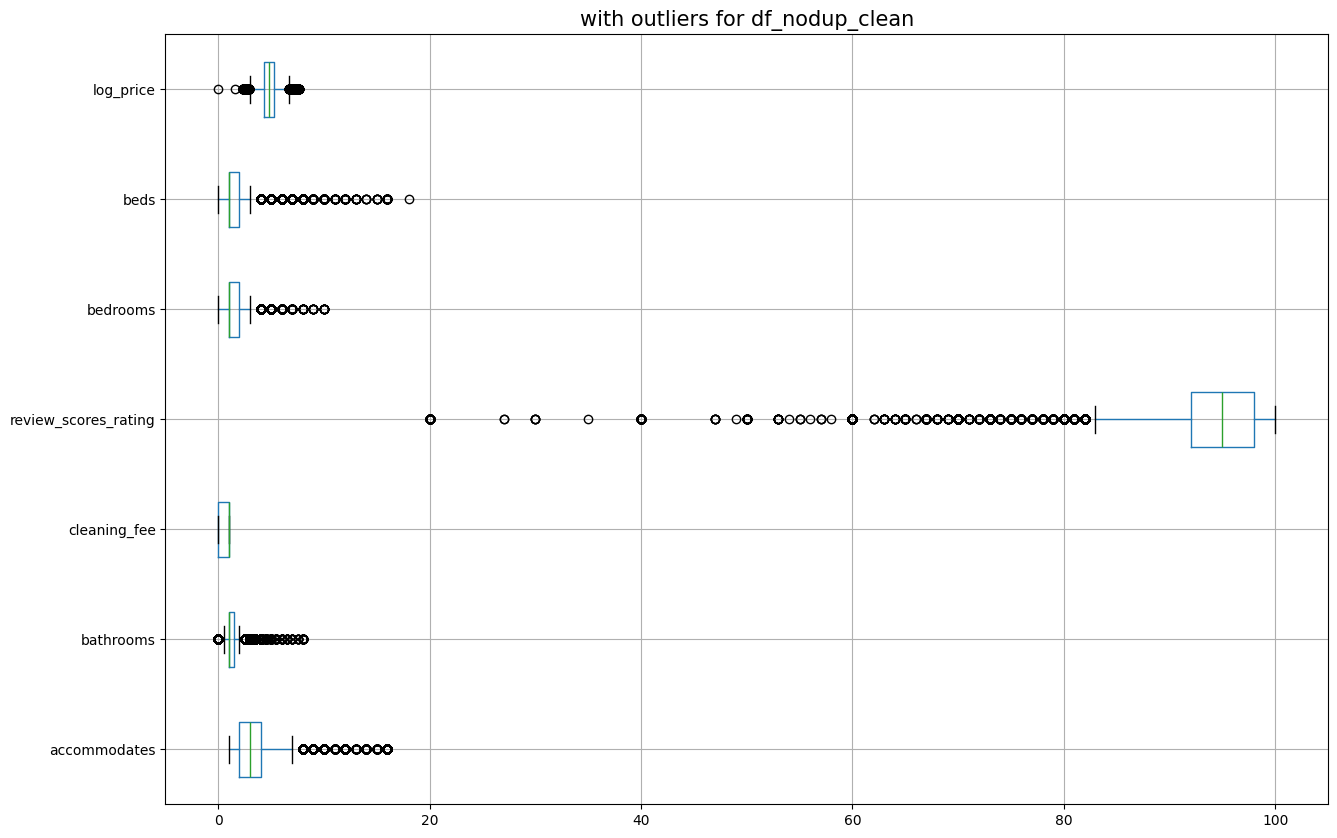

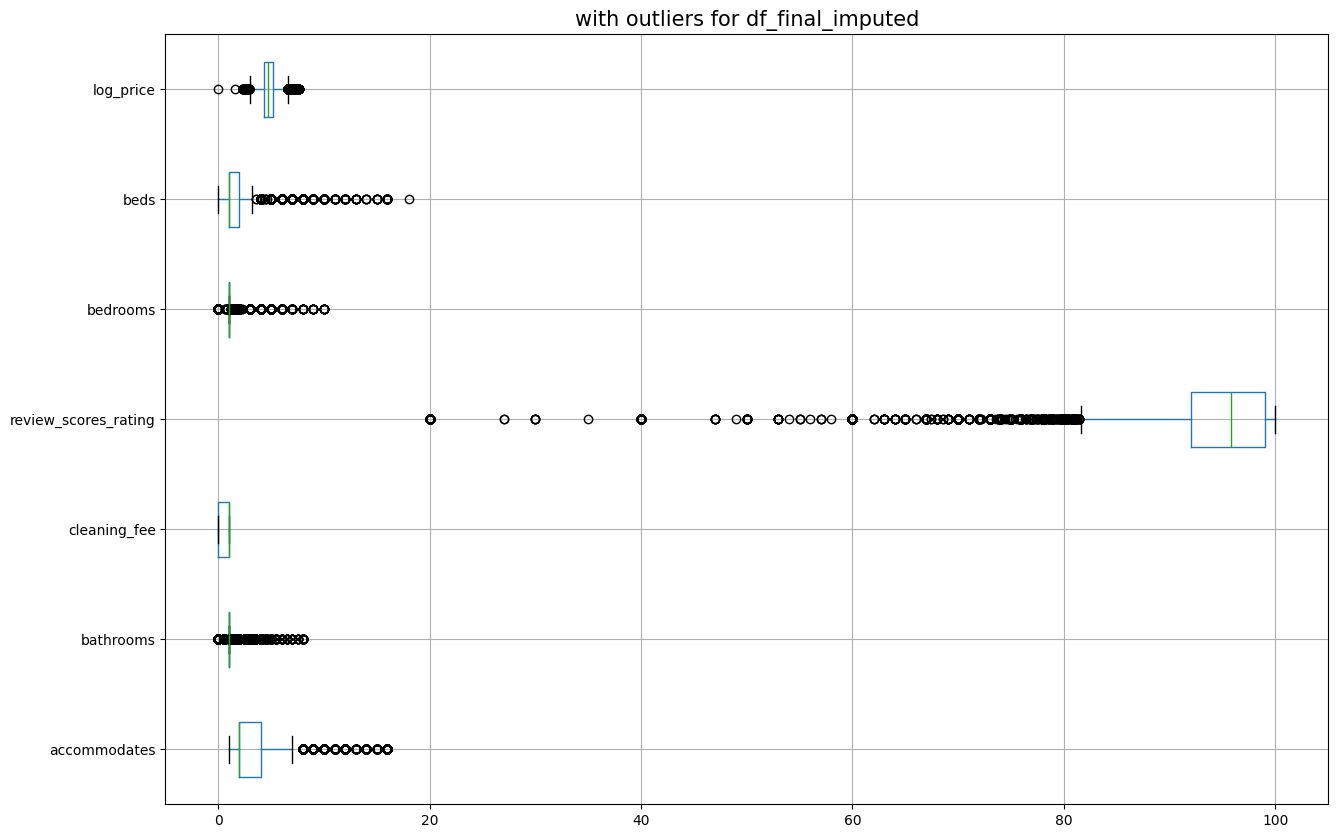

In [47]:
# box plot of all numeric features of df_original_clean
outliers_plot(df_original_clean, "df_original_clean")

# box plot of all numeric features of df_nodup_clean
outliers_plot(df_nodup_clean, "df_nodup_clean")

# box plot of all numeric features of df_final_imputed
outliers_plot(df_final_imputed, "df_final_imputed")


## Outlier Treatment Strategies

To understand the impact of outliers on model performance, two data preparation approaches were adopted for each main dataset variant:

1. **Capping (Winsorization) Approach:**  
   - For all numerical features (except the target, `log_price` and `id`), potential outliers were identified and capped to specified lower and upper bounds (typically based minimum-`1 percentile` and maximum-`99 percentile` permissible lower and upper bounds).
2. **Trimming Approach (Target Outlier Removal):**
   - Observations where the target (`log_price`) fell outside the range [2.3, 7.7] were removed from the dataset. This eliminates unrealistic or highly atypical price values.

These parallel datasets allow comparison of model robustness to different outlier-handling methods.

In [48]:
# Outliers capping function
def cap_outliers(df, num_cols, lower_q=0.01, upper_q=0.99):
    capped_df = df.copy()
    for col in num_cols:
        lower = capped_df[col].quantile(lower_q)
        upper = capped_df[col].quantile(upper_q)
        capped_df[col] = capped_df[col].clip(lower=lower, upper=upper)
    return capped_df


In [49]:
# Choose numeric columns for capping, excluding the target
num_cols = [col for col in df_original_clean.select_dtypes(include='number').columns 
            if col != 'log_price' and col != 'id']

df_original_capped = cap_outliers(df_original_clean, num_cols)
df_nodup_capped = cap_outliers(df_nodup_clean, num_cols)
df_final_capped = cap_outliers(df_final_imputed, num_cols)

In [50]:
# box plot of all numeric features function for all dataframes
def outliers_treated(df,df_name='Dataframe'):
    """
    Plot boxplots for all numeric features in a dataframe.

    Args:
        df (pd.DataFrame): The dataframe to plot.
        df_name (str, optional): The name of the dataframe. Defaults to 'Dataframe'.
    """
    cont = df.select_dtypes(include=[np.number]).columns.drop('id', errors='ignore')
    plt.figure(figsize=(15, 10))
    df[cont].boxplot(vert=False)
    plt.title(f'outliers treated for {df_name}', fontsize=15)
    plt.show()

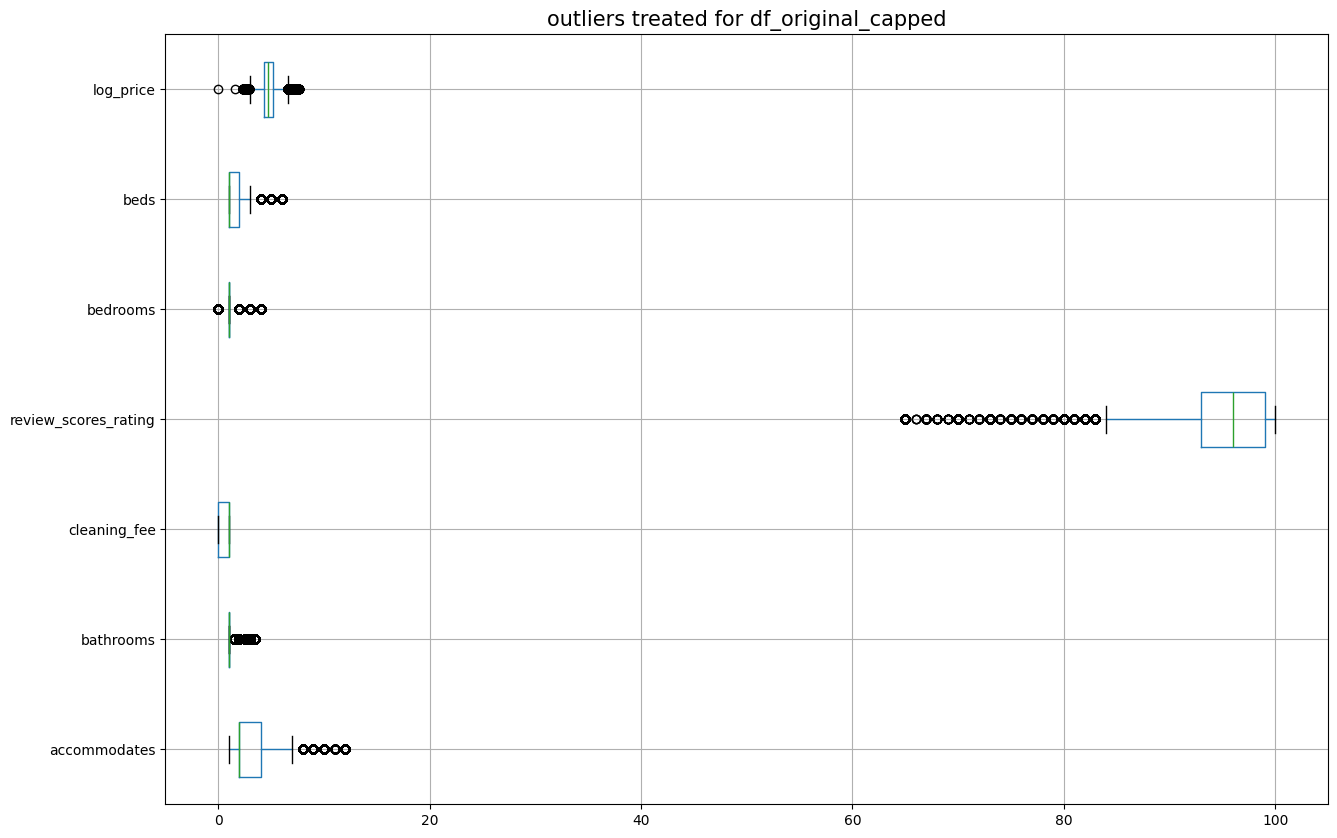

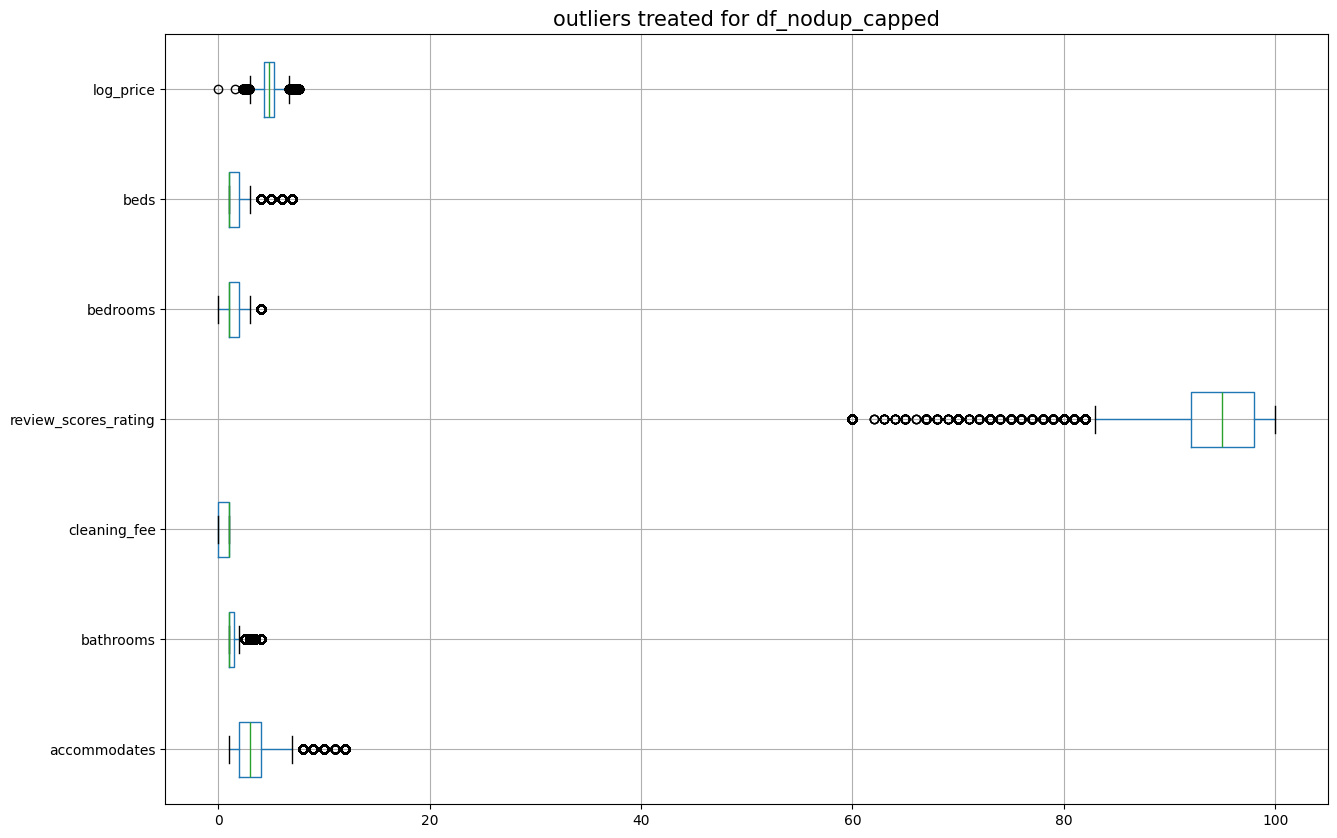

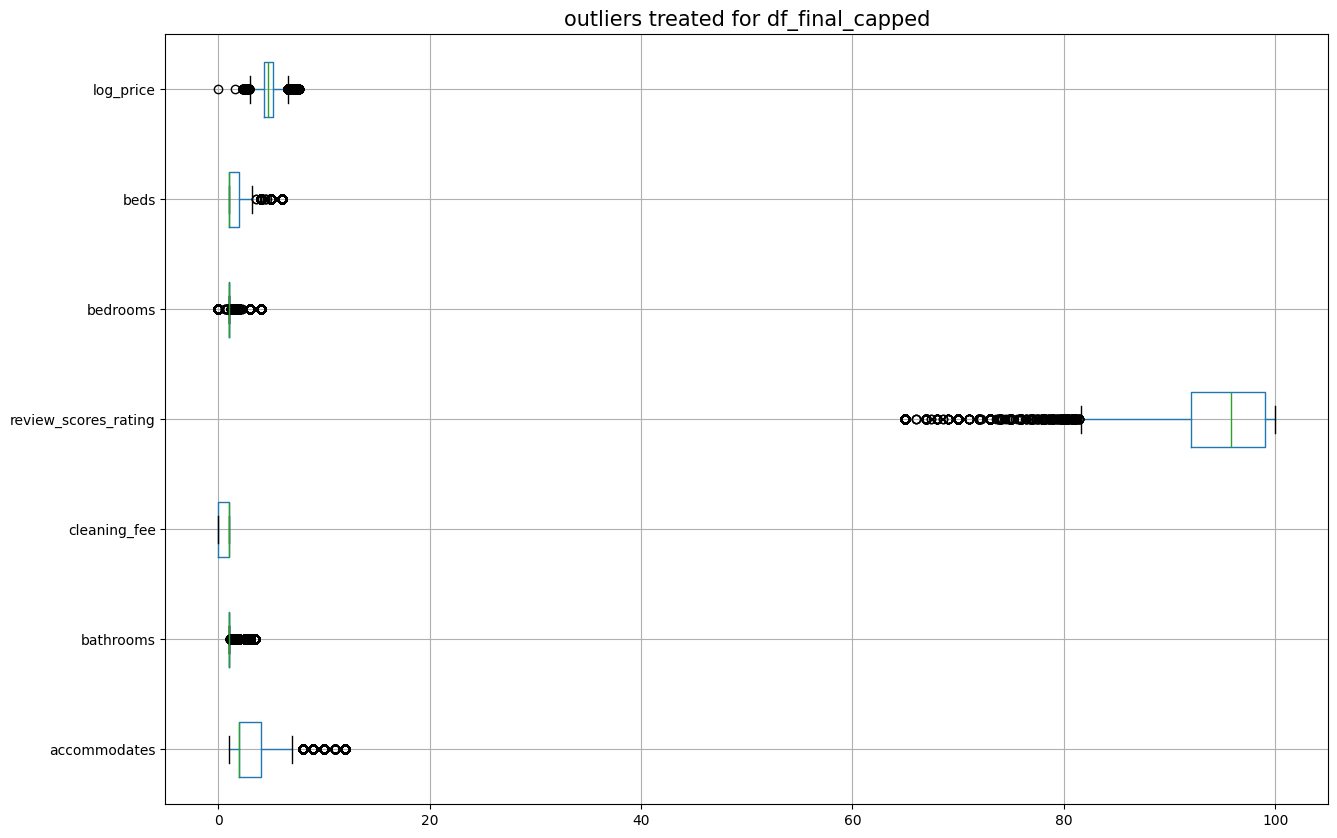

In [51]:
## box plot of all numeric features of df_original_capped
outliers_treated(df_original_capped, "df_original_capped")

# box plot of all numeric features of df_nodup_capped
outliers_treated(df_nodup_capped, "df_nodup_capped")

# box plot of all numeric features of df_final_capped
outliers_treated(df_final_capped, "df_final_capped")



In [52]:
# Trimming for Target Outlier Removal
def trim_target(df, target_col='log_price', lower=2.3, upper=7.7):
    trimmed_df = df[(df[target_col] >= lower) & (df[target_col] <= upper)].reset_index(drop=True)
    return trimmed_df

In [53]:
df_original_trimmed = trim_target(df_original_clean)
df_nodup_trimmed = trim_target(df_nodup_clean)
df_final_trimmed = trim_target(df_final_imputed)

In [54]:
# box plot of all numeric features function for all dataframes
def trim_targeted_outliers(df,df_name='Dataframe'):
    """
    Plot boxplots for all numeric features in a dataframe.

    Args:
        df (pd.DataFrame): The dataframe to plot.
        df_name (str, optional): The name of the dataframe. Defaults to 'Dataframe'.
    """
    cont = df.select_dtypes(include=[np.number]).columns.drop('id', errors='ignore')
    plt.figure(figsize=(15, 10))
    df[cont].boxplot(vert=False)
    plt.title(f'outliers in {df_name} removed based on log_price', fontsize=15)
    plt.show()

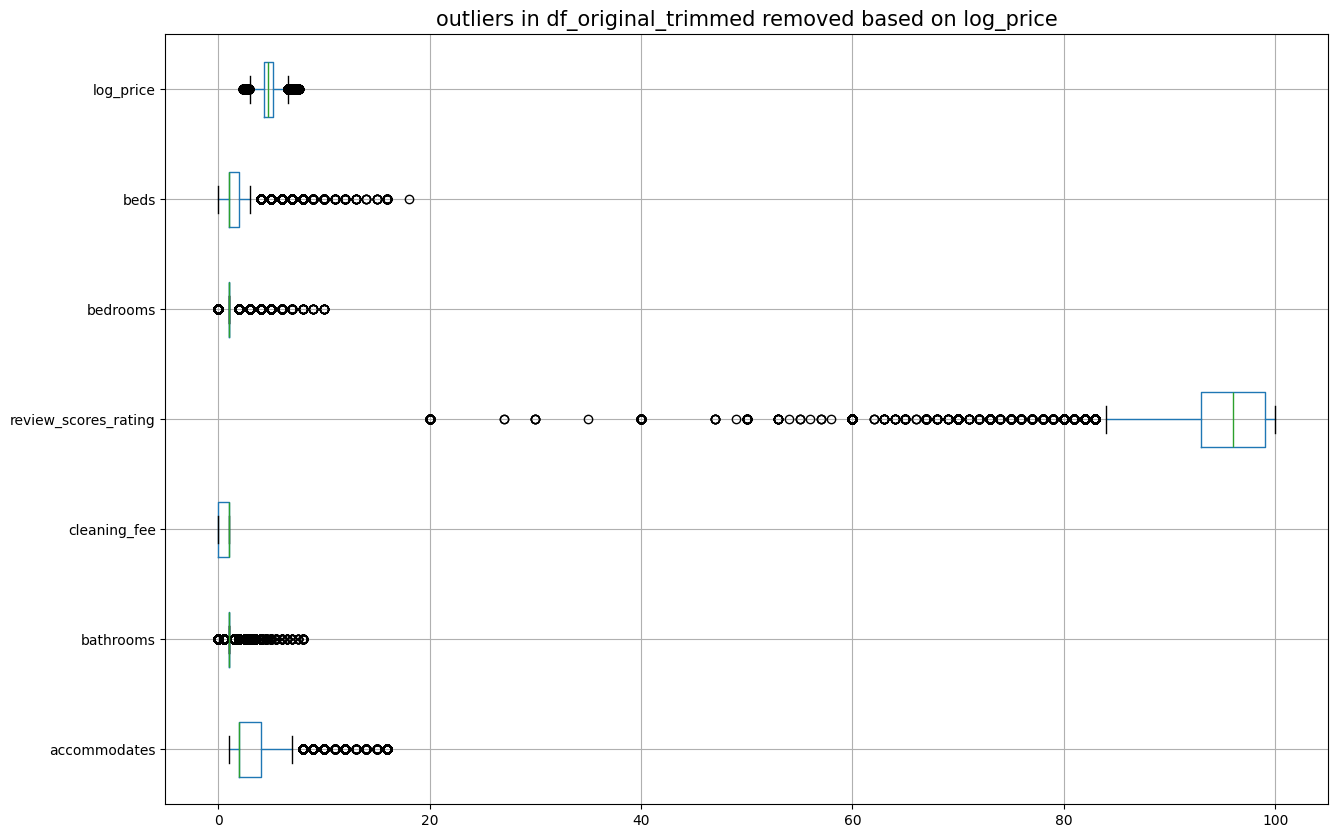

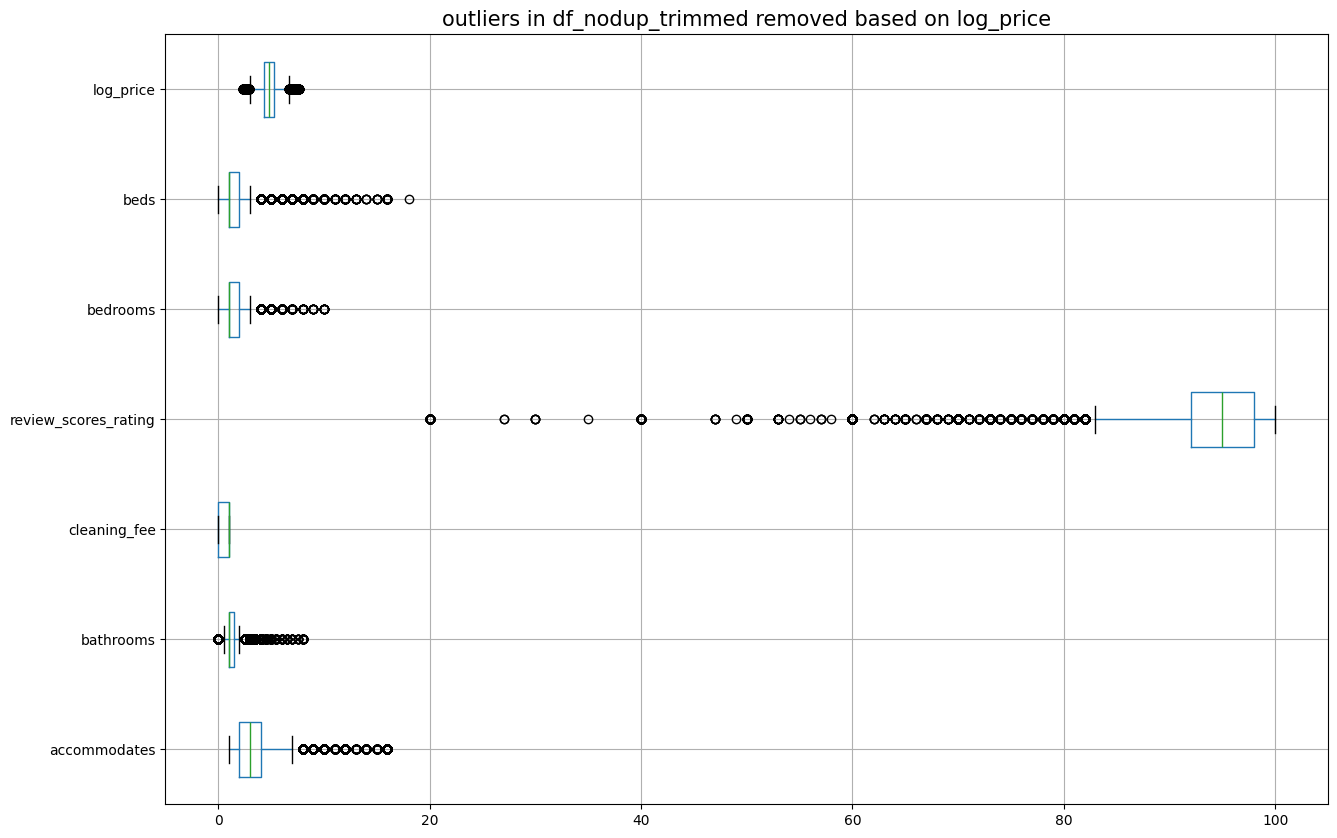

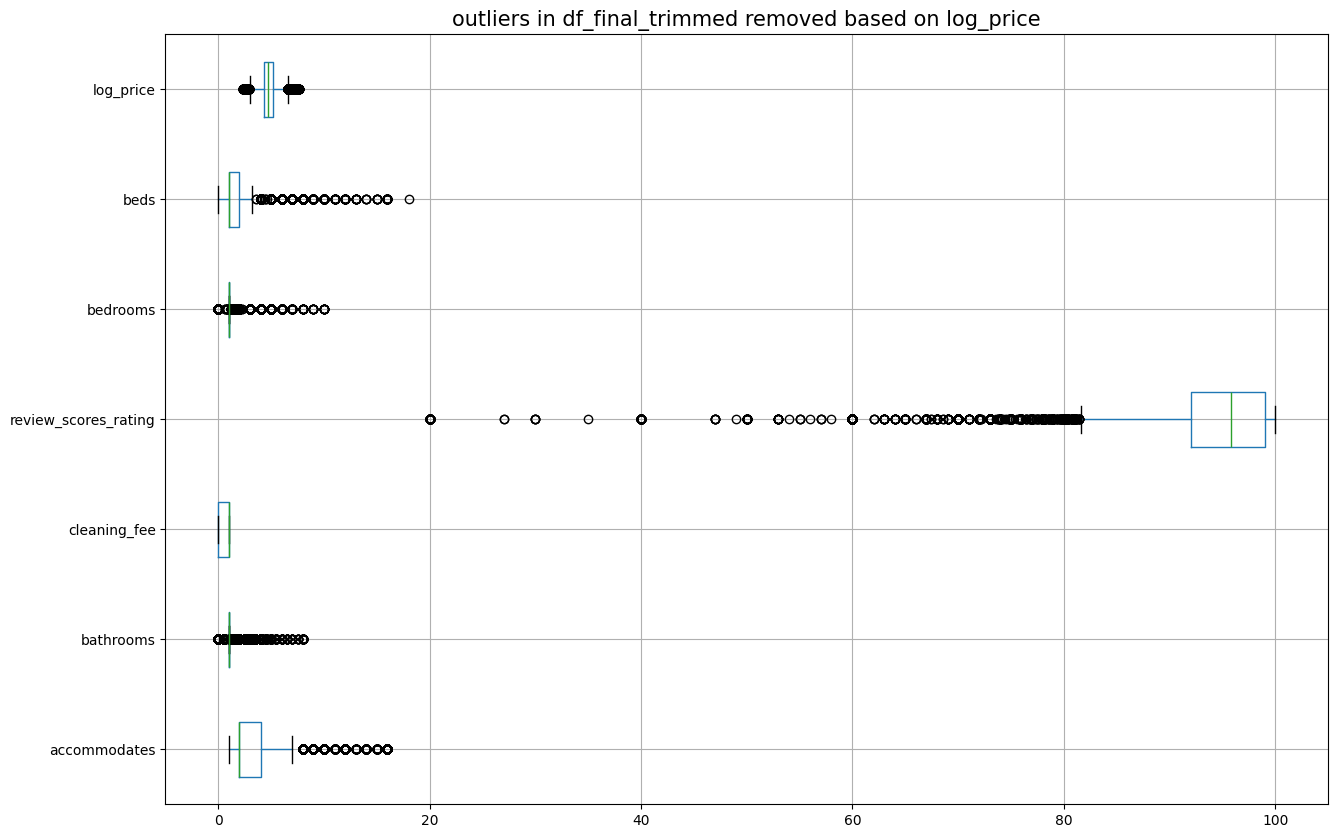

In [55]:
# box plot for all significant numeric features in df_original_trimmed
trim_targeted_outliers(df_original_trimmed, df_name='df_original_trimmed')

# box plot for all significant numeric features in df_nodup_trimmed
trim_targeted_outliers(df_nodup_trimmed, df_name='df_nodup_trimmed')

# box plot for all significant numeric features in df_final_trimmed
trim_targeted_outliers(df_final_trimmed, df_name='df_final_trimmed')


### Data frames list after EDA (handling missing values & outlier treatment)

Based on the EDA conducted, we get the following list of data frames to work with for `feature engineering`:

1. df_original_capped  
2. df_nodup_capped  
3. df_final_capped  
4. df_original_trimmed  
5. df_nodup_trimmed  
6. df_final_trimmed  


In [56]:
# view descriptive statistics of numerical features in df_original_capped exclude id
round(df_original_capped.describe().T.drop('id'), 2)

,count,mean,std,min,25%,50%,75%,max
accommodates,74111.0,3.13,2.04,1.0,2.00,2.00,4.00,12.0
bathrooms,74111.0,1.23,0.51,1.0,1.00,1.00,1.00,3.5
cleaning_fee,74111.0,0.73,0.44,0.0,0.00,1.00,1.00,1.0
review_scores_rating,74111.0,94.64,6.04,65.0,93.00,96.00,99.00,100.0
bedrooms,74111.0,1.25,0.80,0.0,1.00,1.00,1.00,4.0
beds,74111.0,1.68,1.10,1.0,1.00,1.00,2.00,6.0
log_price,74111.0,4.78,0.72,0.0,4.32,4.71,5.22,7.6


In [57]:
# view descriptive statistics of numerical features in df_original_trimmed exclude id
round(df_original_trimmed.describe().T.drop('id'), 2)

,count,mean,std,min,25%,50%,75%,max
accommodates,74109.0,3.16,2.15,1.0,2.00,2.00,4.00,16.0
bathrooms,74109.0,1.23,0.58,0.0,1.00,1.00,1.00,8.0
cleaning_fee,74109.0,0.73,0.44,0.0,0.00,1.00,1.00,1.0
review_scores_rating,74109.0,94.50,6.94,20.0,93.00,96.00,99.00,100.0
bedrooms,74109.0,1.27,0.85,0.0,1.00,1.00,1.00,10.0
beds,74109.0,1.71,1.25,0.0,1.00,1.00,2.00,18.0
log_price,74109.0,4.78,0.72,2.3,4.32,4.71,5.22,7.6


In [58]:
# encoding function
def encode_categoricals(df, drop_first=True):
    df_encoded = df.copy()
    cat_cols = df_encoded.select_dtypes(include=['object', 'category']).columns.tolist()
    
    for col in cat_cols:
        unique_vals = df_encoded[col].dropna().unique()
        if len(unique_vals) == 2:
            val_set = set([str(v).strip().lower() for v in unique_vals])
            if val_set == {'t', 'f'}:
                df_encoded[col] = df_encoded[col].map({'t': 1, 'f': 0})
            elif val_set == {'yes', 'no'}:
                df_encoded[col] = df_encoded[col].map({'yes': 1, 'no': 0})
            elif val_set == {'y', 'n'}:
                df_encoded[col] = df_encoded[col].map({'y': 1, 'n': 0})
            else:
                # Arbitrary binary, one-hot encode as int
                df_encoded = pd.get_dummies(df_encoded, columns=[col], drop_first=drop_first, dtype=int)
        else:
            # Multi-class: one-hot encode as int
            df_encoded = pd.get_dummies(df_encoded, columns=[col], drop_first=drop_first, dtype=int)

    # As a backup, convert any bool columns (in case of previous dummies step)
    for col in df_encoded.select_dtypes(include='bool').columns:
        df_encoded[col] = df_encoded[col].astype(int)
    return df_encoded

A dynamic encoding function was used to:
- Identify all categorical columns in the dataset
- Map common binary variables to 0/1 when possible
- Apply one-hot encoding to all remaining categoricals
- Ensure future-proof, scalable encoding even if the dataset grows in categorical variables

In [59]:
# encoding all 6 dfs
df_original_capped_encoded = encode_categoricals(df_original_capped)
df_original_trimmed_encoded = encode_categoricals(df_original_trimmed)
df_nodup_capped_encoded = encode_categoricals(df_nodup_capped)
df_nodup_trimmed_encoded = encode_categoricals(df_nodup_trimmed)
df_final_capped_encoded = encode_categoricals(df_final_capped)
df_final_trimmed_encoded = encode_categoricals(df_final_trimmed)


In [60]:
# check encoding for df_original_capped (suggested: check the rest for consistency)
df_original_capped_encoded.head()

,id,accommodates,bathrooms,cleaning_fee,instant_bookable,review_scores_rating,bedrooms,beds,log_price,room_type_Private room,room_type_Shared room,cancellation_policy_moderate,cancellation_policy_strict
0,6901257,3.0,1.0,1.0,0,100.0,1.0,1.0,5.010635,0,0,0,1
1,6304928,7.0,1.0,1.0,1,93.0,3.0,3.0,5.129899,0,0,0,1
2,7919400,5.0,1.0,1.0,1,92.0,1.0,3.0,4.976734,0,0,1,0
3,13418779,4.0,1.0,1.0,0,96.0,2.0,2.0,6.620073,0,0,0,0
4,3808709,2.0,1.0,1.0,1,65.0,0.0,1.0,4.744932,0,0,1,0


### Model building

**Define a Model Training and Evaluation Function**
- this function:
    -   Takes a DataFrame
    -   Splits, scales, fits all 3 models
    -   Returns results in a dictionary.

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def run_regression_models(df, df_name=''):
    # Drop id and separate features/target
    X = df.drop(columns=['id', 'log_price'])
    y = df['log_price']

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Define models
    models = {
        'Linear Regression': LinearRegression(),
        'Ridge Regression': Ridge(alpha=1.0),
        'Lasso Regression': Lasso(alpha=0.1)
    }
    results = []  # Will be a list of dicts

    for name, model in models.items():
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        results.append({
            'Dataset': df_name,
            'Model': name,
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
            'MAE': mean_absolute_error(y_test, y_pred),
            'R2': r2_score(y_test, y_pred)
        })
    return results

**Run on All DataFrames and Aggregate**

In [62]:
# You need a list of tuples (df, df_name)
all_dfs = [
    (df_original_capped_encoded, 'Original Capped'),
    (df_original_trimmed_encoded, 'Original Trimmed'),
    (df_nodup_capped_encoded, 'NoDup Capped'),
    (df_nodup_trimmed_encoded, 'NoDup Trimmed'),
    (df_final_capped_encoded, 'Final Imputed Capped'),
    (df_final_trimmed_encoded, 'Final Imputed Trimmed')
]

all_results = []
for df, name in all_dfs:
    results = run_regression_models(df, df_name=name)
    all_results.extend(results)

# Convert results to a DataFrame for easy comparison:
results_df = pd.DataFrame(all_results)
#print(results_df)
results_df

,Dataset,Model,RMSE,MAE,R2
0,Original Capped,Linear Regression,0.496431,0.376941,0.520281
1,Original Capped,Ridge Regression,0.496432,0.376941,0.520281
2,Original Capped,Lasso Regression,0.535154,0.404028,0.442525
3,Original Trimmed,Linear Regression,0.488846,0.371700,0.528970
4,Original Trimmed,Ridge Regression,0.488846,0.371700,0.528970
5,Original Trimmed,Lasso Regression,0.525894,0.398346,0.454869
6,NoDup Capped,Linear Regression,0.527313,0.403958,0.505455
7,NoDup Capped,Ridge Regression,0.527313,0.403958,0.505454
8,NoDup Capped,Lasso Regression,0.560801,0.427298,0.440646
9,NoDup Trimmed,Linear Regression,0.533639,0.403367,0.497854


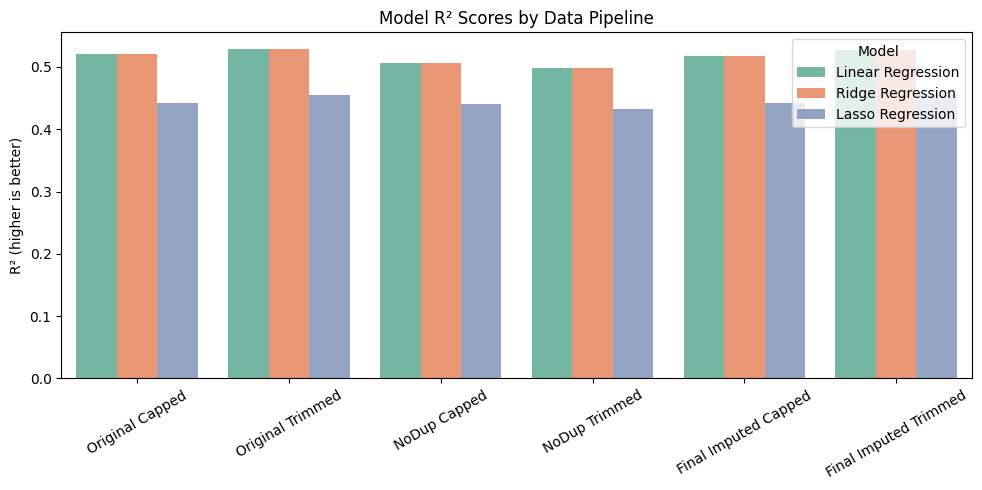

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

palette = "Set2"

plt.figure(figsize=(10,5))
sns.barplot(
    x='Dataset', y='R2', hue='Model',
    data=results_df, palette=palette
)
plt.title('Model R² Scores by Data Pipeline')
plt.ylabel('R² (higher is better)')
plt.xlabel('')
plt.xticks(rotation=30)
plt.legend(title='Model')
plt.tight_layout()
plt.show()

### Model Performance Reflection & Opportunities for Improvement

- The regression models(Linear & Ridge) achieved R² values of approximately `0.52–0.53` which is the highest of all, consistent with published results for open Airbnb datasets with similar feature sets. 
-   The **trimmed** (targeted outlier removal based on log_price) version of models with median and mode imputations seems to show the best accuracy amongst the others, suggesting the outliers could be left untreated for now.
-   The **lasso regression** clearly seems to struggle with accuracy compared to Linear & Ridge models
-   Based on the current scenario Original Trimmed(either linear or ridge) seems to be the best out of the lot
- These results indicate that, with the given features (accommodations, room type, bathrooms, booking policies, review scores, etc.), the model can explain about half the variation in rental price. This is useful for guidance but leaves substantial unexplained variability.

**Future Features for Improved Performance:**
To achieve better predictive power, additional features would be beneficial, such as:
- **Geographical location:** Latitude/longitude, neighborhood, or proximity to popular attractions, transit, or business centers.
- **Time-related features:** Date of listing, seasonal demand, special event indicators, booking window (advance notice).
- **Listing specifics:** Property amenities (Wi-Fi, air conditioning), property description keywords, photos, renovation/newness, host status (Superhost, response time).
- **Market dynamics:** Local competitor pricing, occupancy rates, listing age, review counts, and trends over time.
- **Host-related features:** Host experience, number of listings managed, cancellation/response rates.

**Conclusion:**  
*The model’s performance shows the possibilities and limitations given the available inputs. Expanding the feature set and engineering relevant, high-signal attributes is key for building best-in-class Airbnb price prediction solutions.*

## Export Results to CSV

In [ ]:
results_df.to_csv("model_results_comparison.csv", index=False)

### Save Your Best Model and Scaler with Pickle

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import pickle

# Assume df_best is your chosen DataFrame variant (e.g., df_original_trimmed_encoded)
X_best = df_original_trimmed_encoded.drop(columns=['id', 'log_price'])
y_best = df_original_trimmed_encoded['log_price']

# Scale the features on all data
scaler = StandardScaler()
X_best_scaled = scaler.fit_transform(X_best)

# Fit best model
best_model = Ridge(alpha=1.0)
best_model.fit(X_best_scaled, y_best)

# Save model and scaler together as a tuple
with open('ridge_model_and_scaler.pkl', 'wb') as f:
    pickle.dump((best_model, scaler), f)

### How to Load and Use Later:

In [ ]:
# Uncomment to use
"""
    import pickle

# Load model and scaler
with open('ridge_model_and_scaler.pkl', 'rb') as f:
    loaded_model, loaded_scaler = pickle.load(f)

# Example prediction
# X_new should be a DataFrame with same columns as used in training
X_new_scaled = loaded_scaler.transform(X_new)
preds = loaded_model.predict(X_new_scaled)

"""

### Exporting Results and Saving Models

- The summary of all model performances was exported to `model_results_comparison.csv` for reporting and portfolio inclusion.
- The best-performing regression model and its associated scaler were serialized and saved using `pickle`, allowing for easy deployment or further analysis in new environments.